<a href="https://colab.research.google.com/github/Ande404/CNN-vs-VIT-Agribench/blob/vit-model/vit_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mounting Google Drive

To access files stored in your Google Drive, you need to mount it. Run the following cell and follow the instructions to authorize access.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!find /content/drive -type d -name "CNN-vs-VIT-Agribench" 2>/dev/null

/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench


In [3]:
import os

base = "/content/drive/MyDrive"
for root, dirs, files in os.walk(base):
    for d in dirs:
        if "plant" in d.lower() or "cnn" in d.lower() or "vit" in d.lower():
            print(os.path.join(root, d))

/content/drive/MyDrive/CNN-vs-VIT-Agribench
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/subset/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/raw/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/processed/PlantVillage


In [4]:
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"

In [5]:
import torch
import torch.nn as nn
import os

project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
checkpoint_dir = os.path.join(project_root, "model_checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

model = nn.Linear(10, 2)  # temporary test model

torch.save(model.state_dict(), os.path.join(checkpoint_dir, "model.pth"))
print("Model saved successfully")

Model saved successfully


In [6]:
src_path = os.path.join(project_root, 'src')
print("src exists:", os.path.exists(src_path))

if os.path.exists(src_path):
    print("contents of src:")
    print(os.listdir(src_path))

src exists: True
contents of src:
['utils', '.ipynb_checkpoints']


In [52]:
utils_path = os.path.join(src_path, 'utils')
config_path = os.path.join(utils_path, 'config.py')

print("utils exists:", os.path.exists(utils_path))
print("config.py exists:", os.path.exists(config_path))

utils exists: True
config.py exists: True


In [53]:
from google.colab import drive
import sys
import os

# Standard mount to access the config file initially
drive.mount('/content/drive', force_remount=True)

project_src_path = '/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src'
sys.path.append(project_src_path)

print(f"Checking contents of: {project_src_path}")
if os.path.exists(project_src_path):
    for item in os.listdir(project_src_path):
        print(item)
else:
    print(f"Error: The directory {project_src_path} does not exist.")

# Try to import after path update and verification
from utils.config import initialize_project
initialize_project()

Mounted at /content/drive
Checking contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/src
utils
.ipynb_checkpoints
Authenticated as: DexterAmaning
Working Directory: /content/drive/.shortcut-targets-by-id/1KWxtEStb4FXHFm1hkCECuQcXqK1IOAeK/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench


In [9]:
import os

project_root_check = "/content/drive/MyDrive/Deep-Learning-Final-Project"

if os.path.exists(project_root_check):
    print(f"The folder '{project_root_check}' exists.")
else:
    print(f"The folder '{project_root_check}' does NOT exist.")

The folder '/content/drive/MyDrive/Deep-Learning-Final-Project' exists.


In [10]:
print('Listing contents of /content/drive/MyDrive/Deep-Learning-Final-Project:')
!ls /content/drive/MyDrive/Deep-Learning-Final-Project

Listing contents of /content/drive/MyDrive/Deep-Learning-Final-Project:
 CNN-vs-VIT-Agribench
'Deep Learning Project: Progress Report.gslides'
'Deep Learning Project Proposal.gslides'
'PROJECT PLAN.gdoc'


In [11]:
import os
import copy
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [12]:
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
data_dir = os.path.join(project_root, "data/processed/PlantVillage")
checkpoint_dir = os.path.join(project_root, "model_checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
MODEL_NAME = "vit_b_16"

Using device: cuda


In [13]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [14]:
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
data_dir = os.path.join(project_root, "data/processed/PlantVillage")
checkpoint_dir = os.path.join(project_root, "model_checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
MODEL_NAME = "vit_b_16"

Using device: cuda


In [15]:
import os

print(f"Listing contents of: {data_dir}")
try:
    for item in os.listdir(data_dir):
        print(item)
except FileNotFoundError:
    print(f"Error: Directory not found at {data_dir}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
train
val
test


In [16]:
!find /content/drive/MyDrive -maxdepth 5

/content/drive/MyDrive
/content/drive/MyDrive/Deep-Learning-Final-Project (1)
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/subset
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/subset/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/raw
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/raw/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/processed
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/processed/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/model_checkpoints
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/model_checkpoints/model.pth


In [17]:
import os

project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
data_dir = os.path.join(project_root, "data/processed/PlantVillage")

print(f"Listing contents of: {data_dir}")
try:
    # Only list directories to confirm the expected folder structure (train, val, test)
    contents = [item for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item))]
    if contents:
        print("Found directories:")
        for item in contents:
            print(f"- {item}")
    else:
        print("No subdirectories found in PlantVillage. Expected 'train', 'val', 'test'.")
except FileNotFoundError:
    print(f"Error: Directory not found at {data_dir}. Please ensure the path is correct and the directory exists.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
Found directories:
- train
- val
- test


In [18]:
import os

if os.path.exists(data_dir):
    print(f"The directory '{data_dir}' exists.")
else:
    print(f"The directory '{data_dir}' does NOT exist.")

The directory '/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage' exists.


In [19]:
train_dir = os.path.join(project_root, "train")
val_dir   = os.path.join(project_root, "val")

### Model Initialization and Setup

This section initializes all necessary components for model training, including imports, project path configurations, data transformations, data loaders, the model architecture, and the optimizer/loss function.

In [20]:
import os
import copy
import time
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [21]:
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
data_dir = os.path.join(project_root, "data/processed/PlantVillage")
checkpoint_dir = os.path.join(project_root, "model_checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BATCH_SIZE = 32
NUM_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
MODEL_NAME = "vit_b_16"

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Checkpoint directory: {checkpoint_dir}")

Using device: cuda
Project root: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench
Data directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
Checkpoint directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/model_checkpoints


In [22]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print("Image transformations defined.")

Image transformations defined.


In [23]:
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

print(f"Checking data directories:")
print(f"  Train directory: {train_dir}")
print(f"  Validation directory: {val_dir}")
print(f"  Test directory: {test_dir}")

if not os.path.exists(train_dir) or not os.path.exists(val_dir) or not os.path.exists(test_dir):
    print("\n❌ ERROR: One or more data directories (train, val, test) not found.")
    print(f"Please ensure the data is correctly structured in: {data_dir}")
else:
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    class_names = train_dataset.classes
    num_classes = len(class_names)

    print("\n✅ DataLoaders created successfully.")
    print("Classes:", class_names)
    print("Number of classes:", num_classes)

Checking data directories:
  Train directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/train
  Validation directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/val
  Test directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/test

✅ DataLoaders created successfully.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 5


In [24]:
if 'train_dataset' in locals() and train_dataset:
    targets = [label for _, label in train_dataset.samples]
    class_counts = np.bincount(targets)
    print("Class counts:", class_counts)

    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    print("Class weights:", class_weights)
else:
    print("Skipping class weight calculation: train_dataset not available.")

Class counts: [ 797 1182  800  800  121]
Class weights: tensor([0.4876, 0.3288, 0.4858, 0.4858, 3.2119], device='cuda:0')


In [25]:
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)

in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

model = model.to(device)

print(f"Model '{MODEL_NAME}' initialized and moved to {device}.")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 88.0MB/s]


Model 'vit_b_16' initialized and moved to cuda.


In [26]:
if 'class_weights' in locals():
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()
    print("Warning: class_weights not found, using CrossEntropyLoss without weights.")

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Criterion, Optimizer, and Scheduler defined.")

Criterion, Optimizer, and Scheduler defined.


In [27]:
import os

print(f"Listing contents of: {data_dir}")
try:
    # Only list directories to confirm the expected folder structure (train, val, test)
    contents = [item for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item))]
    if contents:
        print("Found directories:")
        for item in contents:
            print(f"- {item}")
    else:
        print("No subdirectories found in PlantVillage. Expected 'train', 'val', 'test'.")
except FileNotFoundError:
    print(f"Error: Directory not found at {data_dir}. Please ensure the path is correct and the directory exists.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
Found directories:
- train
- val
- test


In [28]:
import os

print(f"Listing contents of the project root directory: {project_root}")

# List contents of the project root
try:
    print(f"Contents of {project_root}:")
    for item in os.listdir(project_root):
        print(f"- {item}")

    # Attempt to list contents of data/processed/PlantVillage if it exists
    potential_data_dir = os.path.join(project_root, "data/processed/PlantVillage")
    if os.path.exists(potential_data_dir):
        print(f"\nContents of {potential_data_dir}:")
        for item in os.listdir(potential_data_dir):
            print(f"- {item}")
    else:
        print(f"\nDirectory '{potential_data_dir}' does not exist. Checking 'data/processed'...")

        potential_processed_dir = os.path.join(project_root, "data/processed")
        if os.path.exists(potential_processed_dir):
            print(f"\nContents of {potential_processed_dir}:")
            for item in os.listdir(potential_processed_dir):
                print(f"- {item}")
        else:
            print(f"\nDirectory '{potential_processed_dir}' does not exist. Checking 'data'...")

            potential_data_base_dir = os.path.join(project_root, "data")
            if os.path.exists(potential_data_base_dir):
                print(f"\nContents of {potential_data_base_dir}:")
                for item in os.listdir(potential_data_base_dir):
                    print(f"- {item}")
            else:
                print(f"\nDirectory '{potential_data_base_dir}' does not exist. Please check your data path.")

except FileNotFoundError:
    print(f"Error: Project root directory not found at {project_root}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of the project root directory: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench
Contents of /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench:
- data
- src
- configs
- results
- .git
- .ipynb_checkpoints
- LICENSE
- notebooks
- README.md
- .gitignore
- cnn_vs_vit-logo.png
- model_checkpoints

Contents of /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage:
- train
- val
- test


In [29]:
print('Searching entire Google Drive for \'PlantVillage\' or \'data\' related directories (this might take a moment):')
!find /content/drive -type d \( -iname "*plantvillage*" -o -iname "*data*" \)

Searching entire Google Drive for 'PlantVillage' or 'data' related directories (this might take a moment):
/content/drive/.shortcut-targets-by-id/1KWxtEStb4FXHFm1hkCECuQcXqK1IOAeK/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data
/content/drive/.shortcut-targets-by-id/1KWxtEStb4FXHFm1hkCECuQcXqK1IOAeK/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/raw/PlantVillage
/content/drive/.shortcut-targets-by-id/1KWxtEStb4FXHFm1hkCECuQcXqK1IOAeK/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/subset/PlantVillage
/content/drive/.shortcut-targets-by-id/1KWxtEStb4FXHFm1hkCECuQcXqK1IOAeK/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/subset/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Project (1)/CNN-vs-VIT-Agribench/data/raw/PlantVillage
/content/drive/MyDrive/Deep-Learning-Final-Pr

In [30]:
import os

print(f"Listing contents of: {data_dir}")
try:
    # Only list directories to confirm the expected folder structure (train, val, test)
    contents = [item for item in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, item))]
    if contents:
        print("Found directories:")
        for item in contents:
            print(f"- {item}")
    else:
        print("No subdirectories found in PlantVillage. Expected 'train', 'val', 'test'.")
except FileNotFoundError:
    print(f"Error: Directory not found at {data_dir}. Please ensure the path is correct and the directory exists.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
Found directories:
- train
- val
- test


In [31]:
print('Listing contents of /content/drive/MyDrive:')
!ls /content/drive/MyDrive

Listing contents of /content/drive/MyDrive:
 CNN-vs-VIT-Agribench
 config
 Deep-Learning-Final-Project
'Deep-Learning-Final-Project (1)'
 Deep-Learning-Final-Project-20260410T213257Z-3-002.zip


In [32]:
import os

project_path = '/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench'
print(f"Contents of {project_path}:")
try:
    for item in os.listdir(project_path):
        print(item)
except FileNotFoundError:
    print(f"Error: Directory not found at {project_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Contents of /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench:
data
src
configs
results
.git
.ipynb_checkpoints
LICENSE
notebooks
README.md
.gitignore
cnn_vs_vit-logo.png
model_checkpoints


In [33]:
import os

project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"

print(f"Listing contents of: {project_root}")
try:
    for item in os.listdir(project_root):
        print(item)

    data_sub_dir = os.path.join(project_root, "data")
    if os.path.exists(data_sub_dir):
        print(f"\nListing contents of: {data_sub_dir}")
        for item in os.listdir(data_sub_dir):
            print(item)
    else:
        print(f"\nDirectory '{data_sub_dir}' does not exist.")

    processed_sub_dir = os.path.join(project_root, "data/processed")
    if os.path.exists(processed_sub_dir):
        print(f"\nListing contents of: {processed_sub_dir}")
        for item in os.listdir(processed_sub_dir):
            print(item)
    else:
        print(f"\nDirectory '{processed_sub_dir}' does not exist.")

except FileNotFoundError:
    print(f"Error: Project root directory not found at {project_root}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench
data
src
configs
results
.git
.ipynb_checkpoints
LICENSE
notebooks
README.md
.gitignore
cnn_vs_vit-logo.png
model_checkpoints

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data
raw
.ipynb_checkpoints
subset
processed

Listing contents of: /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed
PlantVillage


In [34]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [35]:
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

print(f"Debug: data_dir = {data_dir}")
print(f"Debug: train_dir = {train_dir}")
print(f"Debug: val_dir = {val_dir}")
print(f"Debug: test_dir = {test_dir}")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0, # Changed from NUM_WORKERS
    pin_memory=False # Changed from True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0, # Changed from NUM_WORKERS
    pin_memory=False # Changed from True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0, # Changed from NUM_WORKERS
    pin_memory=False # Changed from True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Debug: data_dir = /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage
Debug: train_dir = /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/train
Debug: val_dir = /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/val
Debug: test_dir = /content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench/data/processed/PlantVillage/test
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 5


In [36]:
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
print("Class counts:", class_counts)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Class counts: [ 797 1182  800  800  121]
Class weights: tensor([0.4876, 0.3288, 0.4858, 0.4858, 3.2119], device='cuda:0')


In [37]:
weights = models.ViT_B_16_Weights.DEFAULT
model = models.vit_b_16(weights=weights)

in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, num_classes)

model = model.to(device)

In [38]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")

    return epoch_loss, epoch_acc, epoch_f1

In [40]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

In [41]:
def save_checkpoint(state, filename):
    torch.save(state, filename)

In [42]:
def load_checkpoint(model, optimizer, scheduler, filename, device):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_f1 = checkpoint["best_val_f1"]
    history = checkpoint["history"]
    return model, optimizer, scheduler, start_epoch, best_val_f1, history

In [43]:
import os # Added to fix NameError for 'os'
import torch.nn as nn # Ensure nn is imported if not globally available, though it should be.
import time # Import the time module

# Added to ensure checkpoint_dir and MODEL_NAME are defined
project_root = "/content/drive/MyDrive/Deep-Learning-Final-Project/CNN-vs-VIT-Agribench"
checkpoint_dir = os.path.join(project_root, "model_checkpoints")
MODEL_NAME = "vit_b_16"
NUM_EPOCHS = 15 # Added to fix NameError for 'NUM_EPOCHS'

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1 = 0.0
best_epoch = -1
start_epoch = 0

best_model_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_best.pth")
last_model_path = os.path.join(checkpoint_dir, f"{MODEL_NAME}_last.pth")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 50)

    start_time = time.time()

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, val_labels, val_preds = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    epoch_time = time.time() - start_time

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"Epoch Time: {epoch_time:.2f}s")

    # Save last checkpoint every epoch
    save_checkpoint({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_f1": best_val_f1,
        "history": history,
        "class_names": class_names,
        "model_name": MODEL_NAME
    }, last_model_path)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        save_checkpoint({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_f1": best_val_f1,
            "history": history,
            "class_names": class_names,
            "model_name": MODEL_NAME
        }, best_model_path)

        print(f"Saved best model at epoch {best_epoch} with Val F1 = {best_val_f1:.4f}")

print(f"\nTraining complete. Best epoch: {best_epoch}, Best Val F1: {best_val_f1:.4f}")


Epoch [1/15]
--------------------------------------------------
Train Loss: 0.1871 | Train Acc: 0.9378 | Train F1: 0.9424
Val   Loss: 0.0211 | Val   Acc: 0.9914 | Val   F1: 0.9914
Epoch Time: 1308.07s
Saved best model at epoch 1 with Val F1 = 0.9914

Epoch [2/15]
--------------------------------------------------
Train Loss: 0.0671 | Train Acc: 0.9805 | Train F1: 0.9810
Val   Loss: 0.0154 | Val   Acc: 0.9957 | Val   F1: 0.9957
Epoch Time: 188.76s
Saved best model at epoch 2 with Val F1 = 0.9957

Epoch [3/15]
--------------------------------------------------
Train Loss: 0.0668 | Train Acc: 0.9800 | Train F1: 0.9804
Val   Loss: 0.0272 | Val   Acc: 0.9914 | Val   F1: 0.9915
Epoch Time: 208.64s

Epoch [4/15]
--------------------------------------------------
Train Loss: 0.0585 | Train Acc: 0.9822 | Train F1: 0.9828
Val   Loss: 0.0127 | Val   Acc: 0.9978 | Val   F1: 0.9978
Epoch Time: 187.15s
Saved best model at epoch 4 with Val F1 = 0.9978

Epoch [5/15]
----------------------------------

In [44]:
print(f"'train_one_epoch' function is defined: {'train_one_epoch' in globals()}")
print(f"'validate_one_epoch' function is defined: {'validate_one_epoch' in globals()}")

'train_one_epoch' function is defined: True
'validate_one_epoch' function is defined: True


In [45]:
import matplotlib.pyplot as plt

### Training and Validation Metrics

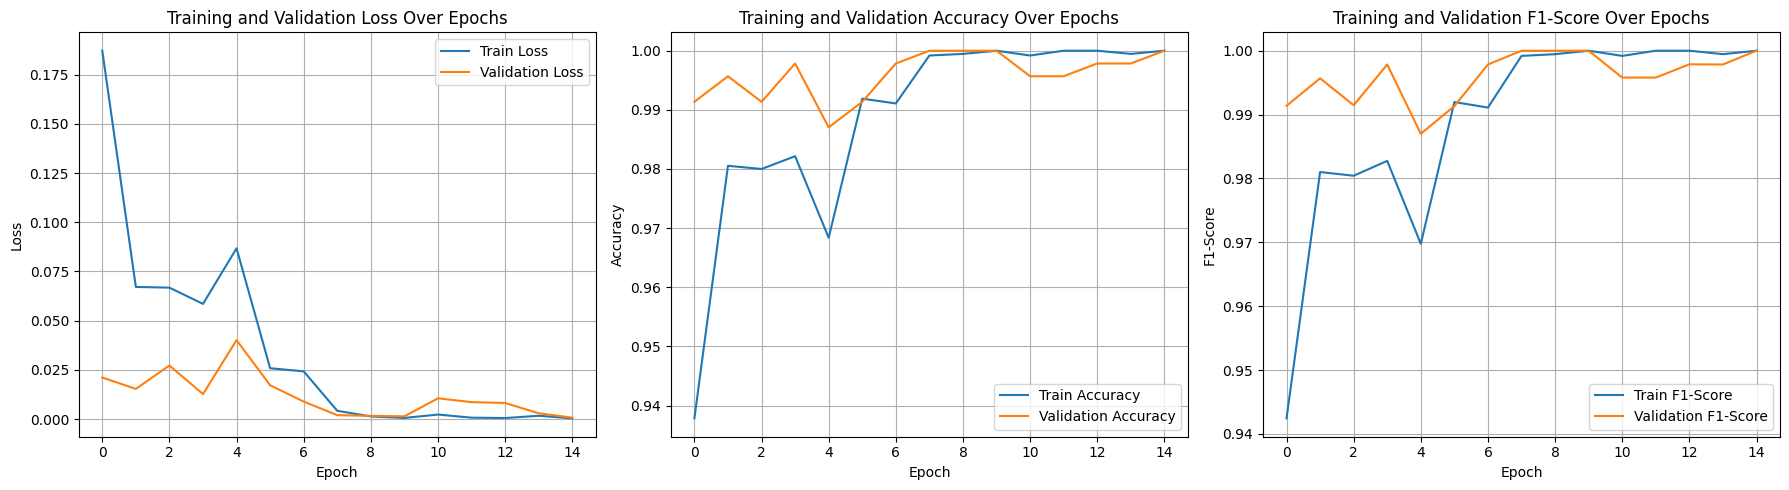

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot F1-Score
plt.subplot(1, 3, 3)
plt.plot(history['train_f1'], label='Train F1-Score')
plt.plot(history['val_f1'], label='Validation F1-Score')
plt.title('Training and Validation F1-Score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [48]:
if 'model' in locals():
    print("The 'model' object is defined.")
    print(f"Type of model: {type(model)}")
else:
    print("The 'model' object is NOT defined.")


The 'model' object is defined.
Type of model: <class 'torchvision.models.vision_transformer.VisionTransformer'>


In [49]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

3700
463
464


In [50]:
import torchvision.transforms as transforms

transforms.Compose([
    transforms.Resize((224, 224)), # Corrected to provide a valid size
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # Added example mean and std
])

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

In [51]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4
